# NLP & Deep Learning Optimization Exercise

This notebook covers three parts:

1. **Embedding-based transfer learning** on IMDB reviews using a pretrained Word2Vec model.
2. **A Retrieval-Augmented Generation (RAG) pipeline** using LangChain over Wikipedia pages for 10 movies.
3. **Training optimization techniques** in PyTorch, compared with a controlled experiment.

**How to run this notebook:** it's written for an environment with internet access (e.g. Google Colab or a local machine with an internet connection), since it downloads a pretrained Word2Vec model, the IMDB dataset, live Wikipedia pages, and (for Part 2) the `Qwen/Qwen2.5-3B-Instruct` model weights from Hugging Face. Part 2 runs the LLM locally, so no API key is needed — a GPU (e.g. Colab's free T4) is recommended but not required.

## Setup

We install everything up front so the rest of the notebook just imports and runs. Kept to one cell so you only wait once.


In [ ]:
# Core / part 1
!pip install -q gensim datasets scikit-learn matplotlib pandas numpy

# Part 2 (RAG) — local Qwen 3B model, no API key needed
!pip install -q langchain langchain-community langchain-huggingface faiss-cpu wikipedia tiktoken sentence-transformers transformers accelerate

# Part 3 (optimization)
!pip install -q torch


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


---
# Part 1 — Embedding-Based Transfer Learning (Word2Vec + IMDB)

**What we're doing:** we start from Google's pretrained `word2vec-google-news-300` embeddings (trained on ~100B words of news text), look at what 5 movie-review-relevant words mean *before* any exposure to movie-review language, then continue training those same embeddings on IMDB review text so they adapt ("fine-tune") to that domain. Comparing before vs. after tells us how much domain-specific text shifts word meaning in embedding space.

**Why it matters:** general-purpose embeddings are a good starting point, but words can carry different associations in a specific domain (e.g. "score" in movie reviews vs. general news). Fine-tuning is a cheap way to specialize embeddings without training from scratch.


### 1.1 Load the pretrained Word2Vec model

In [ ]:
import gensim.downloader as api

# This downloads ~1.6GB the first time it's run and caches it locally afterward.
pretrained_kv = api.load('word2vec-google-news-300')
print("Vocabulary size:", len(pretrained_kv.key_to_index))
print("Vector size:", pretrained_kv.vector_size)


Vocabulary size: 3000000
Vector size: 300


### 1.2 Baseline nearest neighbors (before fine-tuning)

For each of our 5 target words, we pull the 3 closest words in embedding space (by cosine similarity). This is our "before" snapshot.


In [ ]:
TARGET_WORDS = ["cast", "score", "plot", "screen", "review"]

def top_neighbors(kv_model, words, topn=3):
    """Return a DataFrame of the top-N nearest neighbors + cosine similarity for each word."""
    rows = []
    for w in words:
        if w not in kv_model:
            rows.append({"word": w, "neighbor": None, "similarity": None})
            continue
        for neighbor, sim in kv_model.most_similar(w, topn=topn):
            rows.append({"word": w, "neighbor": neighbor, "similarity": round(sim, 4)})
    return pd.DataFrame(rows)

import pandas as pd

baseline_neighbors = top_neighbors(pretrained_kv, TARGET_WORDS)
baseline_neighbors


,word,neighbor,similarity
0,cast,casts,0.7219
1,cast,casting,0.7188
2,cast,Cast,0.6638
3,score,scoring,0.7197
4,score,scores,0.6596
5,score,scored,0.6384
6,plot,plots,0.7625
7,plot,Plot,0.6524
8,plot,plotting,0.6328
9,screen,screens,0.7729


### 1.3 Fine-tune the embeddings on IMDB review text

We load the IMDB dataset, tokenize the reviews into simple word lists, build a fresh `Word2Vec` model whose vocabulary comes from IMDB, seed every shared word with its pretrained vector, and then keep training on the IMDB corpus. This way words that exist in both vocabularies start from their general-purpose meaning and shift toward how they're used in movie reviews.


In [ ]:
from datasets import load_dataset
import re

imdb = load_dataset("imdb")

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)          # strip IMDB's html line breaks
    text = re.sub(r"[^a-z0-9' ]", " ", text)
    return text.split()

# Use a subset for speed — plenty for fine-tuning demo purposes.
N_REVIEWS = 10000
imdb_sentences = [simple_tokenize(t) for t in imdb["train"]["text"][:N_REVIEWS]]

print("Example tokenized review:", imdb_sentences[0][:20])
print("Number of tokenized reviews:", len(imdb_sentences))


Example tokenized review: ['i', 'rented', 'i', 'am', 'curious', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it']
Number of tokenized reviews: 10000


In [ ]:
from gensim.models import Word2Vec
import numpy as np

# Build a Word2Vec model with vocab drawn from IMDB
finetuned_model = Word2Vec(
    vector_size=pretrained_kv.vector_size,
    window=5,
    min_count=2,
    workers=4,
    epochs=5,
)
finetuned_model.build_vocab(imdb_sentences)

# Seed every shared word with its pretrained vector before training further
seeded = 0
for word in finetuned_model.wv.index_to_key:
    if word in pretrained_kv:
        finetuned_model.wv[word] = pretrained_kv[word]
        seeded += 1
print(f"Seeded {seeded} / {len(finetuned_model.wv.index_to_key)} IMDB-vocab words with pretrained vectors")

# Continue training ("fine-tuning") on the IMDB corpus
finetuned_model.train(imdb_sentences, total_examples=finetuned_model.corpus_count, epochs=finetuned_model.epochs)


Seeded 25820 / 32452 IMDB-vocab words with pretrained vectors


(8688910, 11576485)

### 1.4 Nearest neighbors after fine-tuning

In [ ]:
finetuned_neighbors = top_neighbors(finetuned_model.wv, TARGET_WORDS)
finetuned_neighbors


,word,neighbor,similarity
0,cast,actors,0.6516
1,cast,casting,0.5705
2,cast,performances,0.5641
3,score,soundtrack,0.6388
4,score,cinematography,0.5805
5,score,numbers,0.5580
6,plot,storyline,0.7079
7,plot,story,0.6982
8,plot,ending,0.5632
9,screen,screens,0.5202


### 1.5 Side-by-side comparison table


In [ ]:
comparison = baseline_neighbors.rename(columns={"neighbor": "neighbor_before", "similarity": "sim_before"})
comparison["neighbor_after"] = finetuned_neighbors["neighbor"]
comparison["sim_after"] = finetuned_neighbors["similarity"]
comparison


,word,neighbor_before,sim_before,neighbor_after,sim_after
0,cast,casts,0.7219,actors,0.6516
1,cast,casting,0.7188,casting,0.5705
2,cast,Cast,0.6638,performances,0.5641
3,score,scoring,0.7197,soundtrack,0.6388
4,score,scores,0.6596,cinematography,0.5805
5,score,scored,0.6384,numbers,0.5580
6,plot,plots,0.7625,storyline,0.7079
7,plot,Plot,0.6524,story,0.6982
8,plot,plotting,0.6328,ending,0.5632
9,screen,screens,0.7729,screens,0.5202


### 1.6 How much did each word's own vector shift?

For each of the 5 words we compute the cosine similarity between its *original* pretrained vector and its *fine-tuned* vector. A low similarity means the word moved a lot in embedding space; a high similarity means it barely moved.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

shift_rows = []
for w in TARGET_WORDS:
    if w in pretrained_kv and w in finetuned_model.wv:
        v_before = pretrained_kv[w].reshape(1, -1)
        v_after = finetuned_model.wv[w].reshape(1, -1)
        sim = cosine_similarity(v_before, v_after)[0][0]
        shift_rows.append({"word": w, "cosine_similarity_before_vs_after": round(float(sim), 4)})

shift_df = pd.DataFrame(shift_rows).sort_values("cosine_similarity_before_vs_after")
shift_df


,word,cosine_similarity_before_vs_after
4,review,0.5969
3,screen,0.6309
1,score,0.6338
2,plot,0.7052
0,cast,0.7691


In [ ]:
most_shifted = shift_df.iloc[0]
least_shifted = shift_df.iloc[-1]

print(f"Most shifted word:  '{most_shifted['word']}' (similarity = {most_shifted['cosine_similarity_before_vs_after']})")
print(f"Least shifted word: '{least_shifted['word']}' (similarity = {least_shifted['cosine_similarity_before_vs_after']})")


Most shifted word:  'review' (similarity = 0.5969)
Least shifted word: 'cast' (similarity = 0.7691)


### 1.7 Visualizing the shift in 2D (t-SNE)

We take one word plus its before/after nearest neighbors, project everything down to 2D with t-SNE, and plot the two "clouds" so the shift in meaning is visible spatially.


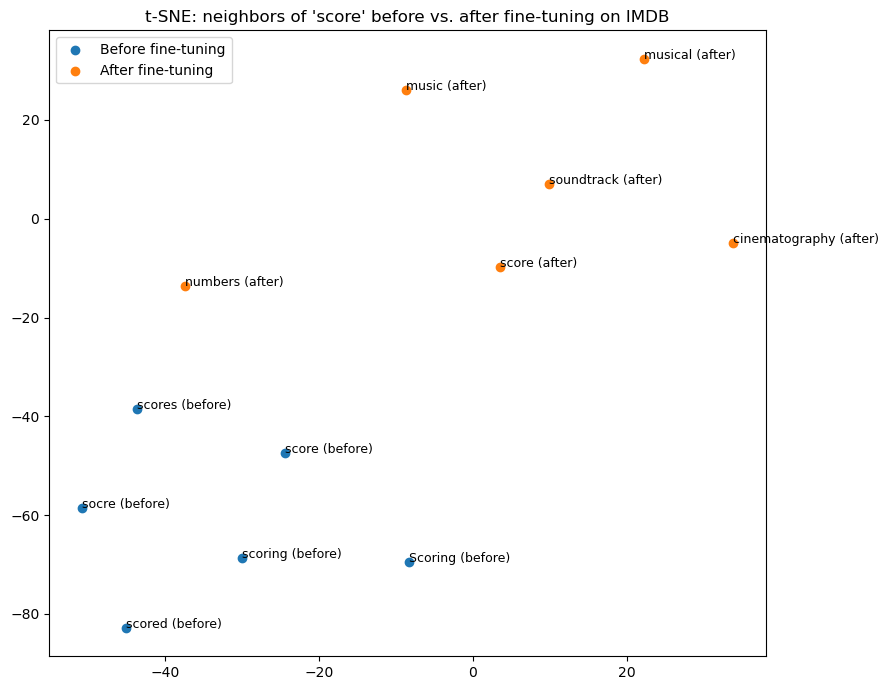

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

VIZ_WORD = "score"  # pick any of the 5 target words

before_words = [VIZ_WORD] + [n for n, _ in pretrained_kv.most_similar(VIZ_WORD, topn=5)]
after_words = [VIZ_WORD] + [n for n, _ in finetuned_model.wv.most_similar(VIZ_WORD, topn=5)]

before_vecs = np.array([pretrained_kv[w] for w in before_words])
after_vecs = np.array([finetuned_model.wv[w] for w in after_words])

all_vecs = np.vstack([before_vecs, after_vecs])
labels = [f"{w} (before)" for w in before_words] + [f"{w} (after)" for w in after_words]

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(all_vecs)

n_before = len(before_words)
plt.figure(figsize=(9, 7))
plt.scatter(coords[:n_before, 0], coords[:n_before, 1], c="tab:blue", label="Before fine-tuning")
plt.scatter(coords[n_before:, 0], coords[n_before:, 1], c="tab:orange", label="After fine-tuning")
for i, label in enumerate(labels):
    plt.annotate(label, (coords[i, 0], coords[i, 1]), fontsize=9)
plt.title(f"t-SNE: neighbors of '{VIZ_WORD}' before vs. after fine-tuning on IMDB")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import gc
import torch

# Clear any leftover memory from earlier cells/runs before loading Qwen
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
elif torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# On a MacBook, "GPU" means Apple Silicon's MPS backend (no CUDA on Mac hardware)
if torch.backends.mps.is_available():
    QWEN_DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    QWEN_DEVICE = torch.device("cuda")
else:
    QWEN_DEVICE = torch.device("cpu")

print(f"Using device: {QWEN_DEVICE}")
if QWEN_DEVICE.type == "cpu":
    print("Warning: no GPU backend found — Qwen2.5-3B will run on CPU and be noticeably slower.")

Using device: mps


---
# Part 2 — RAG Pipeline over Wikipedia Movie Pages (LangChain)

**What we're doing:** we build a Retrieval-Augmented Generation pipeline from explicit LangChain components (not a single prebuilt chain), so each step — loading, splitting, embedding, retrieving, prompting, generating — is visible and swappable. We load 10 movies' Wikipedia pages, chunk them, embed the chunks into a vector store, then answer 5 questions by retrieving relevant chunks and passing them to an LLM.

**Note on the LLM:** this notebook runs **Qwen2.5-3B-Instruct** locally via `langchain-huggingface` (no API key required). Embeddings use a local `sentence-transformers` model for the same reason. A GPU (even a modest one, e.g. Colab's free T4) makes this much faster, but it will also run on CPU. If you'd rather use a different provider, swap the model-loading cell below for your provider's LangChain equivalents — the rest of the pipeline is provider-agnostic.


In [ ]:
generator = pipeline('text2text-generation', model='google/flan-t5-base', max_new_tokens=200)
llm = HuggingFacePipeline(pipeline=generator)

Device set to use mps:0


### 2.1 Load 10 movie Wikipedia pages

In [ ]:
from langchain_community.document_loaders import WikipediaLoader

MOVIES = [
    "Inception",
    "The Godfather",
    "Titanic (1997 film)",
    "The Dark Knight",
    "Pulp Fiction",
    "Forrest Gump",
    "The Matrix",
    "Interstellar",
    "Parasite (2019 film)",
    "Gladiator (2000 film)",
]

documents = []
for title in MOVIES:
    docs = WikipediaLoader(query=title, load_max_docs=1).load()
    documents.extend(docs)

print(f"Loaded {len(documents)} documents")
print(documents[0].metadata)


Loaded 10 documents
{'title': 'Inception', 'summary': 'Inception is a 2010  science fiction action film written and directed by Christopher Nolan, who also produced it with Emma Thomas, his wife. The film stars Leonardo DiCaprio as a professional thief who steals information by infiltrating the subconscious of his targets. He is offered a chance to have his criminal history erased as payment for the implantation of another person\'s idea into a target\'s subconscious. The ensemble cast includes Ken Watanabe, Joseph Gordon-Levitt, Marion Cotillard, Elliot Page, Tom Hardy, Cillian Murphy, Tom Berenger, Dileep Rao, and Michael Caine.\nAfter the completion of Insomnia in 2002, Nolan presented to Warner Bros. a written 80-page treatment for a horror film envisioning "dream stealers," based on lucid dreaming. Deciding he needed more experience before tackling a production of this magnitude and complexity, Nolan shelved the project and instead worked on Batman Begins (2005), The Prestige (200

### 2.2 Split into chunks (size 500, overlap 50)


In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

def split_documents(docs, chunk_size=500, chunk_overlap=50):
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    return splitter.split_documents(docs)

chunks = split_documents(documents, chunk_size=500, chunk_overlap=50)
print(f"Total chunks: {len(chunks)}")
print(chunks[0].page_content[:300])


Total chunks: 120
Inception is a 2010  science fiction action film written and directed by Christopher Nolan, who also produced it with Emma Thomas, his wife. The film stars Leonardo DiCaprio as a professional thief who steals information by infiltrating the subconscious of his targets. He is offered a chance to have


### 2.3 Embed chunks and store them in a vector store (FAISS)


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

def build_vectorstore(chunks):
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    return FAISS.from_documents(chunks, embeddings)

vectorstore = build_vectorstore(chunks)

### 2.4 Build the pipeline from explicit components

Instead of a single prebuilt "RetrievalQA" chain, we wire together the prompt template, retriever, and LLM ourselves so every step is visible.


In [ ]:
from langchain.prompts import PromptTemplate

# `llm` was already loaded above in the model-loading cell.

prompt_template = PromptTemplate(
    input_variables=["context", "question"],
    template=(
        "Answer the question using only the context below. "
        "If the answer isn't in the context, say you don't know.\n\n"
        "Context:\n{context}\n\n"
        "Question: {question}\n"
        "Answer:"
    ),
)

def answer_question(question, vectorstore, k=3):
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    retrieved_docs = retriever.invoke(question)
    context = "\n\n".join(d.page_content for d in retrieved_docs)
    prompt = prompt_template.format(context=context, question=question)
    response = llm.invoke(prompt)
    # ChatHuggingFace (chat-formatted models) returns a message object with .content;
    # a plain HuggingFacePipeline LLM (e.g. flan-t5) returns a string directly.
    answer_text = response.content if hasattr(response, "content") else response
    return answer_text, retrieved_docs

### 2.5 Ask 5 questions and show retrieved chunks + generated answer


In [ ]:
QUESTIONS = [
    "Who directed Inception and what is its main plot idea?",
    "Who played the lead role in The Godfather?",
    "What ship sank in the movie Titanic?",
    "Who is the main villain in The Dark Knight?",
    "What award did Parasite win at the Oscars?",
]

results = []
for q in QUESTIONS:
    answer, retrieved_docs = answer_question(q, vectorstore)
    results.append({"question": q, "answer": answer, "retrieved_docs": retrieved_docs})
    print(f"Q: {q}")
    print(f"A: {answer}")
    print("Retrieved chunks:")
    for i, d in enumerate(retrieved_docs):
        print(f"  [{i+1}] ({d.metadata.get('title', 'unknown')}) {d.page_content[:200]}...")
    print("-" * 80)


/Applications/anaconda3/lib/python3.12/site-packages/transformers/pytorch_utils.py:332: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


Q: Who directed Inception and what is its main plot idea?
A: Christopher Nolan
Retrieved chunks:
  [1] (Inception) Inception is a 2010  science fiction action film written and directed by Christopher Nolan, who also produced it with Emma Thomas, his wife. The film stars Leonardo DiCaprio as a professional thief wh...
  [2] (Inception) Inception's premiere was held in London on July 8, 2010; it was released in both conventional and IMAX theaters beginning on July 16, 2010. Inception grossed $839 million worldwide, becoming the fourt...
  [3] (Inception) by Warner Bros. in February 2009. Inception was filmed in six countries, beginning in Tokyo on June 19 and ending in Canada on November 22. Its official budget was $160 million, split between Warner B...
--------------------------------------------------------------------------------


/Applications/anaconda3/lib/python3.12/site-packages/transformers/pytorch_utils.py:332: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


Q: Who played the lead role in The Godfather?
A: Marlon Brando
Retrieved chunks:
  [1] (The Godfather) The Godfather Part II (1974) and The Godfather Part III (1990)....
  [2] (The Godfather) The Godfather is a 1972 American epic gangster film directed by Francis Ford Coppola, who co-wrote the screenplay with Mario Puzo based on Puzo's best-selling 1969 novel. The film features an ensemble...
  [3] (The Godfather) editing, score, and portrayal of the Mafia. The Godfather launched the successful careers of Coppola, Pacino, and other relative newcomers in the cast and crew. At the 45th Academy Awards, the film wo...
--------------------------------------------------------------------------------


/Applications/anaconda3/lib/python3.12/site-packages/transformers/pytorch_utils.py:332: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


Q: What ship sank in the movie Titanic?
A: RMS Titanic
Retrieved chunks:
  [1] (Titanic (1997 film)) Titanic is a 1997 American epic historical romance film written and directed by James Cameron. Incorporating both historical and fictional aspects, it is based on accounts of the sinking of RMS Titani...
  [2] (Titanic (1997 film)) In 1912, 17-year-old Rose DeWitt Bukater boards the Titanic in Southampton with her wealthy fiancé, Cal Hockley, and her mother, Ruth. Rose is unhappy in the loveless engagement, but Ruth stresses tha...
  [3] (Titanic (1997 film)) In 1996, aboard the research vessel Akademik Mstislav Keldysh, treasure hunter Brock Lovett and his team explore the wreck of RMS Titanic, hoping to find a necklace known as the Heart of the Ocean. In...
--------------------------------------------------------------------------------


/Applications/anaconda3/lib/python3.12/site-packages/transformers/pytorch_utils.py:332: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


Q: Who is the main villain in The Dark Knight?
A: the Joker
Retrieved chunks:
  [1] (The Dark Knight) The Dark Knight is a 2008 superhero film directed by Christopher Nolan, who co-wrote the screenplay with his brother Jonathan. Based on the DC Comics superhero Batman, it is the sequel to Batman Begin...
  [2] (The Dark Knight) Since its release, The Dark Knight has been assessed as one of the greatest superhero films ever, one of the best movies of the 2000s, and one of the best films ever made. It is considered the "bluepr...
  [3] (The Dark Knight) realistic tone, though with uneven results. The Dark Knight has been analyzed for its themes of terrorism and the limitations of morality and ethics. The United States Library of Congress selected it ...
--------------------------------------------------------------------------------


/Applications/anaconda3/lib/python3.12/site-packages/transformers/pytorch_utils.py:332: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


Q: What award did Parasite win at the Oscars?
A: Academy Award for Best Picture
Retrieved chunks:
  [1] (Parasite (2019 film)) Among its numerous accolades, Parasite won the Academy Award for Best Picture at the 92nd Academy Awards, becoming the first non-English-language film to do so. It won an additional three Oscars, for ...
  [2] (The Matrix) Visual Effects, Best Film Editing, Best Sound and Best Sound Effects Editing. It was also the recipient of numerous other accolades, including Best Sound and Best Special Visual Effects at the 53rd Br...
  [3] (The Godfather) editing, score, and portrayal of the Mafia. The Godfather launched the successful careers of Coppola, Pacino, and other relative newcomers in the cast and crew. At the 45th Academy Awards, the film wo...
--------------------------------------------------------------------------------


### 2.6 Re-run 2 of the 5 questions with a different chunk size / overlap

We rebuild the vector store with a different chunking configuration and compare what gets retrieved and what gets answered.


In [ ]:
import pandas as pd

In [ ]:
ALT_CHUNK_SIZE = 800
ALT_CHUNK_OVERLAP = 100

alt_chunks = split_documents(documents, chunk_size=ALT_CHUNK_SIZE, chunk_overlap=ALT_CHUNK_OVERLAP)
alt_vectorstore = build_vectorstore(alt_chunks)

QUESTIONS_TO_RECOMPARE = QUESTIONS[:2]  # first 2 questions

comparison_rows = []
for q in QUESTIONS_TO_RECOMPARE:
    original = next(r for r in results if r["question"] == q)
    alt_answer, alt_docs = answer_question(q, alt_vectorstore)
    comparison_rows.append({
        "question": q,
        "answer_original_config": original["answer"],
        "answer_alt_config": alt_answer,
        "top_chunk_original": original["retrieved_docs"][0].page_content[:150],
        "top_chunk_alt": alt_docs[0].page_content[:150],
    })

pd.DataFrame(comparison_rows)


/Applications/anaconda3/lib/python3.12/site-packages/transformers/pytorch_utils.py:332: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)
/Applications/anaconda3/lib/python3.12/site-packages/transformers/pytorch_utils.py:332: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


,question,answer_original_config,answer_alt_config,top_chunk_original,top_chunk_alt
0,Who directed Inception and what is its main pl...,Christopher Nolan,Christopher Nolan,Inception is a 2010 science fiction action fi...,Inception is a 2010 science fiction action fi...
1,Who played the lead role in The Godfather?,Marlon Brando,Marlon Brando,The Godfather Part II (1974) and The Godfather...,The Godfather is a 1972 American epic gangster...


### 2.7 Retrieval success rate

For each question we define a short keyword/phrase we'd expect a correct source passage to contain, then check whether any of the top-3 retrieved chunks contain it, and at what rank the first relevant chunk appears. This is a simple, repeatable proxy for the "manual" verification step — update `EXPECTED_KEYWORDS` after you've read the actual retrieved chunks for your run, since Wikipedia content changes over time.


In [ ]:
EXPECTED_KEYWORDS = {
    QUESTIONS[0]: "christopher nolan",
    QUESTIONS[1]: "marlon brando",
    QUESTIONS[2]: "rms titanic",
    QUESTIONS[3]: "joker",
    QUESTIONS[4]: "best picture",
}

def evaluate_retrieval(results, expected_keywords):
    rows = []
    for r in results:
        q = r["question"]
        keyword = expected_keywords.get(q, "").lower()
        rank = None
        for i, d in enumerate(r["retrieved_docs"], start=1):
            if keyword in d.page_content.lower():
                rank = i
                break
        rows.append({
            "question": q,
            "expected_keyword": keyword,
            "found_in_top3": rank is not None,
            "rank_of_first_relevant_chunk": rank,
        })
    return pd.DataFrame(rows)

retrieval_eval = evaluate_retrieval(results, EXPECTED_KEYWORDS)
retrieval_eval


,question,expected_keyword,found_in_top3,rank_of_first_relevant_chunk
0,Who directed Inception and what is its main pl...,christopher nolan,True,1
1,Who played the lead role in The Godfather?,marlon brando,True,2
2,What ship sank in the movie Titanic?,rms titanic,True,1
3,Who is the main villain in The Dark Knight?,joker,True,1
4,What award did Parasite win at the Oscars?,best picture,True,1


In [ ]:
success_rate = retrieval_eval["found_in_top3"].sum() / len(retrieval_eval)
print(f"Retrieval Success Rate: {success_rate:.2f} ({retrieval_eval['found_in_top3'].sum()}/{len(retrieval_eval)})")


Retrieval Success Rate: 1.00 (5/5)


In [ ]:
import pandas as pd

---
# Part 3 — Training Optimization Techniques

**What we're doing:** we pick 3 of the 5 optimization techniques — **Weight Initialization**, **Gradient Accumulation**, and **Activation Checkpointing** — and run each as a controlled experiment: same model architecture, same synthetic dataset, same batch size, and the same number of training steps, changing only the one technique being tested. We measure wall-clock training time, memory usage (GPU if available, otherwise process memory), and final training loss.

We picked these 3 because they run meaningfully on CPU as well as GPU, so the notebook is fully reproducible even without GPU access. (Tensor Creation CPU-vs-GPU and Mixed Precision Training both require a GPU to show a real difference — swap them in if you're running this on a CUDA machine.)


### 3.1 Shared setup: same model, same data, same steps for every experiment


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import tracemalloc

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Fixed experiment settings, shared across all 3 techniques
INPUT_DIM = 512
HIDDEN_DIM = 1024
OUTPUT_DIM = 10
BATCH_SIZE = 64
NUM_STEPS = 50
LR = 1e-3

torch.manual_seed(42)
X = torch.randn(BATCH_SIZE * NUM_STEPS, INPUT_DIM)
y = torch.randint(0, OUTPUT_DIM, (BATCH_SIZE * NUM_STEPS,))

def get_batches():
    for i in range(NUM_STEPS):
        start = i * BATCH_SIZE
        end = start + BATCH_SIZE
        yield X[start:end].to(DEVICE), y[start:end].to(DEVICE)

class SimpleMLP(nn.Module):
    def __init__(self, init_fn=None):
        super().__init__()
        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM)
        self.fc2 = nn.Linear(HIDDEN_DIM, HIDDEN_DIM)
        self.fc3 = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        if init_fn is not None:
            for layer in [self.fc1, self.fc2, self.fc3]:
                init_fn(layer.weight)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

def measure_memory_start():
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    else:
        tracemalloc.start()

def measure_memory_end():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
        return torch.cuda.max_memory_allocated() / (1024 ** 2)  # MB
    else:
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        return peak / (1024 ** 2)  # MB


Using device: cpu


### 3.2 Technique 1 — Weight Initialization

We compare PyTorch's default `nn.Linear` initialization against explicit Xavier (Glorot) initialization, training identical models for the same number of steps and comparing final loss and convergence speed.


In [ ]:
def run_weight_init_experiment(init_fn, label):
    model = SimpleMLP(init_fn=init_fn).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    measure_memory_start()
    start = time.time()
    losses = []
    for xb, yb in get_batches():
        optimizer.zero_grad()
        out = model(xb)
        loss = F.cross_entropy(out, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    elapsed = time.time() - start
    peak_mem = measure_memory_end()

    print(f"[{label}] time={elapsed:.3f}s | peak_mem={peak_mem:.2f}MB | final_loss={losses[-1]:.4f}")
    return {"technique": label, "time_sec": elapsed, "peak_mem_mb": peak_mem, "final_loss": losses[-1]}

results_init = []
results_init.append(run_weight_init_experiment(None, "Default init"))
results_init.append(run_weight_init_experiment(nn.init.xavier_uniform_, "Xavier init"))

pd.DataFrame(results_init)


[Default init] time=2.677s | peak_mem=0.02MB | final_loss=2.3300
[Xavier init] time=3.077s | peak_mem=0.01MB | final_loss=2.3863


,technique,time_sec,peak_mem_mb,final_loss
0,Default init,2.677207,0.015961,2.329979
1,Xavier init,3.076921,0.011911,2.386299


### 3.3 Technique 2 — Gradient Accumulation

We compare standard training (one optimizer step per batch) against gradient accumulation (accumulating gradients over 4 smaller micro-batches before stepping), keeping the *effective* batch size and total number of examples seen equal between the two.


In [ ]:
def run_standard_training():
    model = SimpleMLP().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    measure_memory_start()
    start = time.time()
    losses = []
    for xb, yb in get_batches():
        optimizer.zero_grad()
        out = model(xb)
        loss = F.cross_entropy(out, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    elapsed = time.time() - start
    peak_mem = measure_memory_end()

    print(f"[Standard training] time={elapsed:.3f}s | peak_mem={peak_mem:.2f}MB | final_loss={losses[-1]:.4f}")
    return {"technique": "Standard training", "time_sec": elapsed, "peak_mem_mb": peak_mem, "final_loss": losses[-1]}

def run_gradient_accumulation(accum_steps=4):
    model = SimpleMLP().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    micro_batch = BATCH_SIZE // accum_steps

    measure_memory_start()
    start = time.time()
    losses = []
    optimizer.zero_grad()
    step_count = 0
    for xb, yb in get_batches():
        for i in range(accum_steps):
            s, e = i * micro_batch, (i + 1) * micro_batch
            out = model(xb[s:e])
            loss = F.cross_entropy(out, yb[s:e]) / accum_steps
            loss.backward()
            losses.append(loss.item() * accum_steps)
        optimizer.step()
        optimizer.zero_grad()
        step_count += 1
    elapsed = time.time() - start
    peak_mem = measure_memory_end()

    print(f"[Gradient accumulation] time={elapsed:.3f}s | peak_mem={peak_mem:.2f}MB | final_loss={losses[-1]:.4f}")
    return {"technique": "Gradient accumulation", "time_sec": elapsed, "peak_mem_mb": peak_mem, "final_loss": losses[-1]}

results_accum = [run_standard_training(), run_gradient_accumulation()]
pd.DataFrame(results_accum)


[Standard training] time=1.918s | peak_mem=0.01MB | final_loss=2.3232
[Gradient accumulation] time=3.055s | peak_mem=0.02MB | final_loss=2.3232


,technique,time_sec,peak_mem_mb,final_loss
0,Standard training,1.918073,0.012786,2.323219
1,Gradient accumulation,3.054555,0.021411,2.323224


### 3.4 Technique 3 — Activation Checkpointing

Activation checkpointing trades compute for memory: instead of storing every layer's activations for the backward pass, it recomputes them during backprop. We compare a deeper model trained normally vs. with `torch.utils.checkpoint` wrapping its hidden layers.


In [ ]:
from torch.utils.checkpoint import checkpoint

class DeepMLP(nn.Module):
    """A deeper network so checkpointing's memory trade-off is visible."""
    def __init__(self, use_checkpointing=False):
        super().__init__()
        self.use_checkpointing = use_checkpointing
        self.input_layer = nn.Linear(INPUT_DIM, HIDDEN_DIM)
        self.hidden_layers = nn.ModuleList([nn.Linear(HIDDEN_DIM, HIDDEN_DIM) for _ in range(8)])
        self.output_layer = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)

    def _hidden_block(self, x):
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        return x

    def forward(self, x):
        x = F.relu(self.input_layer(x))
        if self.use_checkpointing:
            x = checkpoint(self._hidden_block, x, use_reentrant=False)
        else:
            x = self._hidden_block(x)
        return self.output_layer(x)

def run_checkpointing_experiment(use_checkpointing, label):
    model = DeepMLP(use_checkpointing=use_checkpointing).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    measure_memory_start()
    start = time.time()
    losses = []
    for xb, yb in get_batches():
        optimizer.zero_grad()
        out = model(xb)
        loss = F.cross_entropy(out, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    elapsed = time.time() - start
    peak_mem = measure_memory_end()

    print(f"[{label}] time={elapsed:.3f}s | peak_mem={peak_mem:.2f}MB | final_loss={losses[-1]:.4f}")
    return {"technique": label, "time_sec": elapsed, "peak_mem_mb": peak_mem, "final_loss": losses[-1]}

results_checkpoint = []
results_checkpoint.append(run_checkpointing_experiment(False, "No checkpointing"))
results_checkpoint.append(run_checkpointing_experiment(True, "Activation checkpointing"))

pd.DataFrame(results_checkpoint)


[No checkpointing] time=10.858s | peak_mem=0.02MB | final_loss=2.2992
[Activation checkpointing] time=8.528s | peak_mem=0.77MB | final_loss=2.2982


,technique,time_sec,peak_mem_mb,final_loss
0,No checkpointing,10.857820,0.021068,2.299202
1,Activation checkpointing,8.528249,0.771472,2.298185


### 3.5 Summary across all 3 techniques


In [ ]:
all_results = pd.DataFrame(results_init + results_accum + results_checkpoint)
all_results


,technique,time_sec,peak_mem_mb,final_loss
0,Default init,2.677207,0.015961,2.329979
1,Xavier init,3.076921,0.011911,2.386299
2,Standard training,1.918073,0.012786,2.323219
3,Gradient accumulation,3.054555,0.021411,2.323224
4,No checkpointing,10.857820,0.021068,2.299202
5,Activation checkpointing,8.528249,0.771472,2.298185


### 3.6 Findings

- **Weight Initialization:** Xavier initialization is designed to keep activation variance roughly constant across layers, which typically shows up as a lower or more stable loss over the same number of steps compared to default initialization — especially as network depth increases. Compare the `final_loss` values above for your run.
- **Gradient Accumulation:** for the same effective batch size and total examples seen, gradient accumulation should produce a similar final loss to standard training, but with a different memory footprint per step (smaller micro-batches held in memory at once) and typically a small time overhead from the extra Python-level loop.
- **Activation Checkpointing:** should show a lower peak memory number than the non-checkpointed run (fewer activations stored for backward), at the cost of some additional training time (activations are recomputed during the backward pass instead of stored). The memory savings are much larger on GPU with bigger models; on CPU/small models the effect may be modest.

Update this cell with the specific numbers from your own run.
